# Cleaning the dataset with missing and inconsistent values

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [51]:
df = pd.read_csv("../data/raw/StressLevelDataset_dirty.csv")
df.head()

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,10.0,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2
1,6.0,26.0,0,8.0,1,2.0,5.0,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0
2,5.0,25.0,NaN,6.0,1,2.0,4.0,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1,10.0,3,1.0,2.0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1
4,19.0,15.0,1,27.0,5,NaN,1.0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2.0


## Checking out the stats for the dataset

In [52]:
df.describe()

,anxiety_level,self_esteem,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,safety,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying
count,1039.000000,1049.000000,1063.000000,1118.000000,1008.000000,1028.000000,1051.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1118.000000,1052.000000,1061.000000,995.000000,1039.000000,1017.000000,1027.000000
mean,11.887392,17.843661,12.921919,2.511628,2.177579,2.778210,2.764986,2.649374,2.516995,2.727191,2.771914,2.769678,2.626118,2.649240,2.641847,1.887437,2.719923,2.751229,2.605648
std,8.603211,9.413546,8.317868,1.407026,0.875130,1.854344,1.406431,1.322810,1.115199,1.401430,1.428962,1.402595,1.314378,1.379326,1.517167,1.040137,1.430300,1.404458,1.518337
min,0.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,11.000000,7.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,11.000000,19.000000,12.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000
75%,17.000000,26.000000,19.000000,3.000000,3.000000,4.000000,4.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000
max,92.000000,99.000000,59.000000,5.000000,5.000000,12.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,5.000000,5.000000,5.000000


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1039 non-null   float64
 1   self_esteem                   1049 non-null   float64
 2   mental_health_history         1020 non-null   object 
 3   depression                    1063 non-null   float64
 4   headache                      1118 non-null   int64  
 5   blood_pressure                1008 non-null   float64
 6   sleep_quality                 1028 non-null   float64
 7   breathing_problem             1051 non-null   float64
 8   noise_level                   1118 non-null   int64  
 9   living_conditions             1118 non-null   int64  
 10  safety                        1118 non-null   int64  
 11  basic_needs                   1118 non-null   int64  
 12  academic_performance          1118 non-null   float64
 13  stu

In [54]:
df.isna().sum()

anxiety_level                    79
self_esteem                      69
mental_health_history            98
depression                       55
headache                          0
blood_pressure                  110
sleep_quality                    90
breathing_problem                67
noise_level                       0
living_conditions                 0
safety                            0
basic_needs                       0
academic_performance              0
study_load                        0
teacher_student_relationship     66
future_career_concerns           57
social_support                  123
peer_pressure                    79
extracurricular_activities      101
bullying                         91
stress_level                      0
dtype: int64

## As we can see, we can't really drop the rows with NAs as it would significantly reduce the size of the dataset

In [55]:
df.dropna(inplace=False)

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
6,16.0,11.0,false,22.0,5,3.0,1.0,4.0,4,2,...,2,1.0,5,2.0,5.0,1.0,4.0,5.0,5.0,2
18,18.0,10.0,1,23.0,3,3.0,1.0,5.0,5,1,...,2,2.0,4,1.0,4.0,1.0,4.0,4.0,4.0,2
22,7.0,25.0,0,0.0,1,2.0,5.0,2.0,1,4,...,5,4.0,2,5.0,1.0,3.0,1.0,1.0,1.0,0
25,13.0,24.0,1,10.0,2,1.0,3.0,4.0,2,2,...,2,2.0,3,3.0,3.0,2.0,2.0,2.0,3.0,1
27,21.0,28.0,0,20.0,0,3.0,0.0,0.0,5,4,...,4,2.0,4,2.0,0.0,0.0,5.0,0.0,5.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1097,16.0,15.0,0,14.0,4,3.0,4.0,5.0,1,2,...,5,3.0,1,1.0,1.0,1.0,5.0,2.0,2.0,2
1100,7.0,27.0,0,7.0,1,2.0,4.0,2.0,1,4,...,5,4.0,2,4.0,1.0,3.0,1.0,1.0,1.0,0
1104,21.0,1.0,1,17.0,3,3.0,1.0,4.0,5,1,...,1,1.0,4,2.0,5.0,1.0,5.0,5.0,5.0,2
1107,8.0,25.0,0,5.0,1,2.0,4.0,1.0,2,4,...,4,4.0,1,4.0,1.0,3.0,1.0,2.0,1.0,0


In [56]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1,25.0,3,3.0,10.0,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2
1,6.0,26.0,0,8.0,1,2.0,5.0,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0
2,5.0,25.0,NaN,6.0,1,2.0,4.0,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1,10.0,3,1.0,2.0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1
4,19.0,15.0,1,27.0,5,NaN,1.0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1113,13.0,23.0,0,NaN,3,1.0,2.0,2.0,3,3,...,3,2.0,3,2.0,2.0,3.0,2.0,3.0,2.0,1
1114,7.0,22.0,0,1.0,5,3.0,5.0,3.0,5,5,...,2,2.0,5,3.0,4.0,NaN,1.0,4.0,4.0,2
1115,13.0,20.0,0,9.0,2,1.0,3.0,4.0,3,3,...,2,3.0,2,3.0,2.0,3.0,3.0,3.0,NaN,1
1116,16.0,12.0,1,22.0,4,3.0,1.0,4.0,3,1,...,2,2.0,5,2.0,5.0,1.0,NaN,5.0,5.0,2


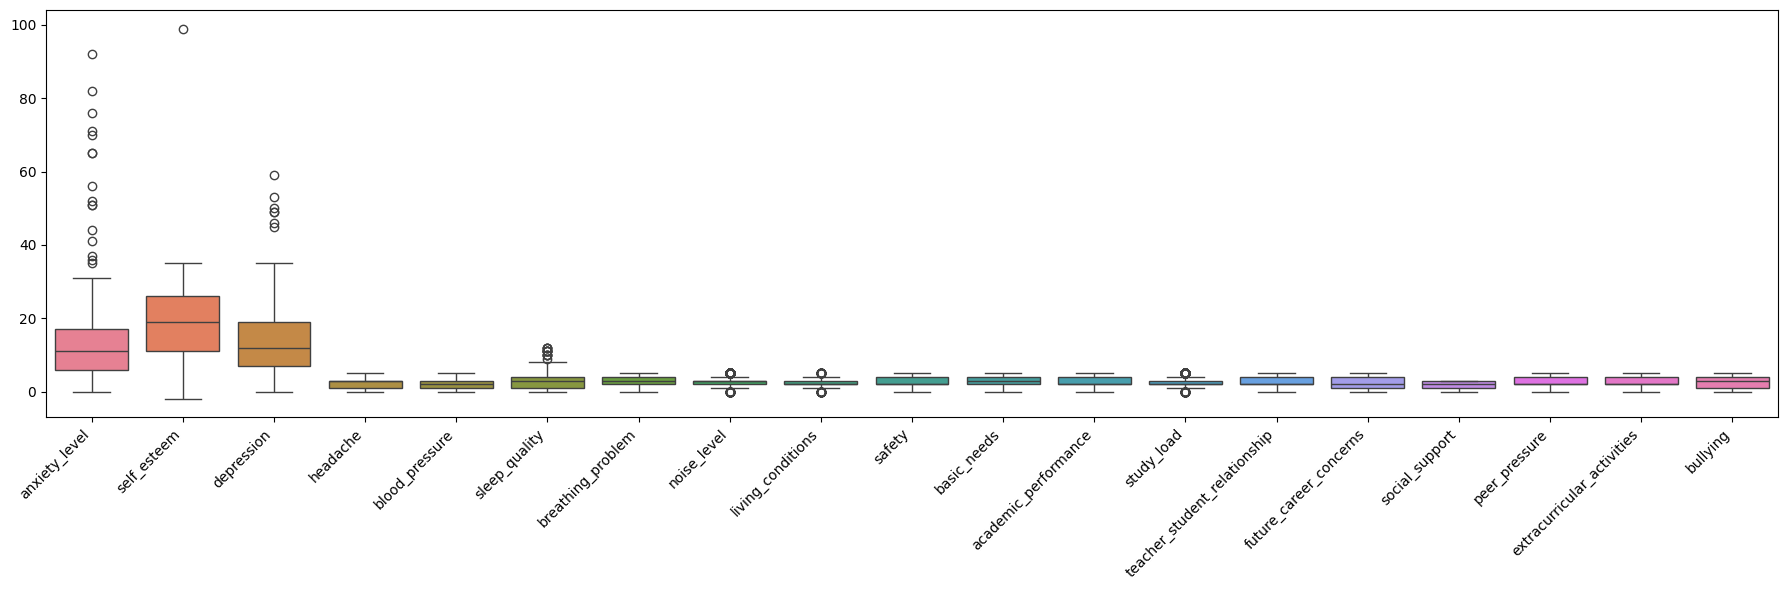

In [57]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [58]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 18
Duplicates after: 0


In [89]:
df['stress_level'] = df['stress_level'].astype(str).str.strip().str.lower()

stress_map = {
    'low': 0, 'medium': 1, 'high': 2,
    '0': 0, '1': 1, '2': 2,
    '0.0': 0, '1.0': 1, '2.0': 2,
    'nan': np.nan
}
df['stress_level'] = df['stress_level'].map(stress_map)

In [90]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1.0,25.0,3,3.0,10.0,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2.0
1,6.0,26.0,0.0,8.0,1,2.0,5.0,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0.0
2,5.0,25.0,NaN,6.0,1,2.0,4.0,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0.0
3,12.0,23.0,1.0,10.0,3,1.0,2.0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1.0
4,19.0,15.0,1.0,27.0,5,NaN,1.0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20.0,28.0,NaN,8.0,3,NaN,2.0,0.0,1,0,...,3,5.0,3,NaN,2.0,1.0,NaN,NaN,5.0,0.0
1096,13.0,23.0,0.0,NaN,3,1.0,2.0,2.0,3,3,...,3,2.0,3,2.0,2.0,3.0,2.0,3.0,2.0,1.0
1097,7.0,22.0,0.0,1.0,5,3.0,5.0,3.0,5,5,...,2,2.0,5,3.0,4.0,NaN,1.0,4.0,4.0,2.0
1098,13.0,20.0,0.0,9.0,2,1.0,3.0,4.0,3,3,...,2,3.0,2,3.0,2.0,3.0,3.0,3.0,NaN,1.0


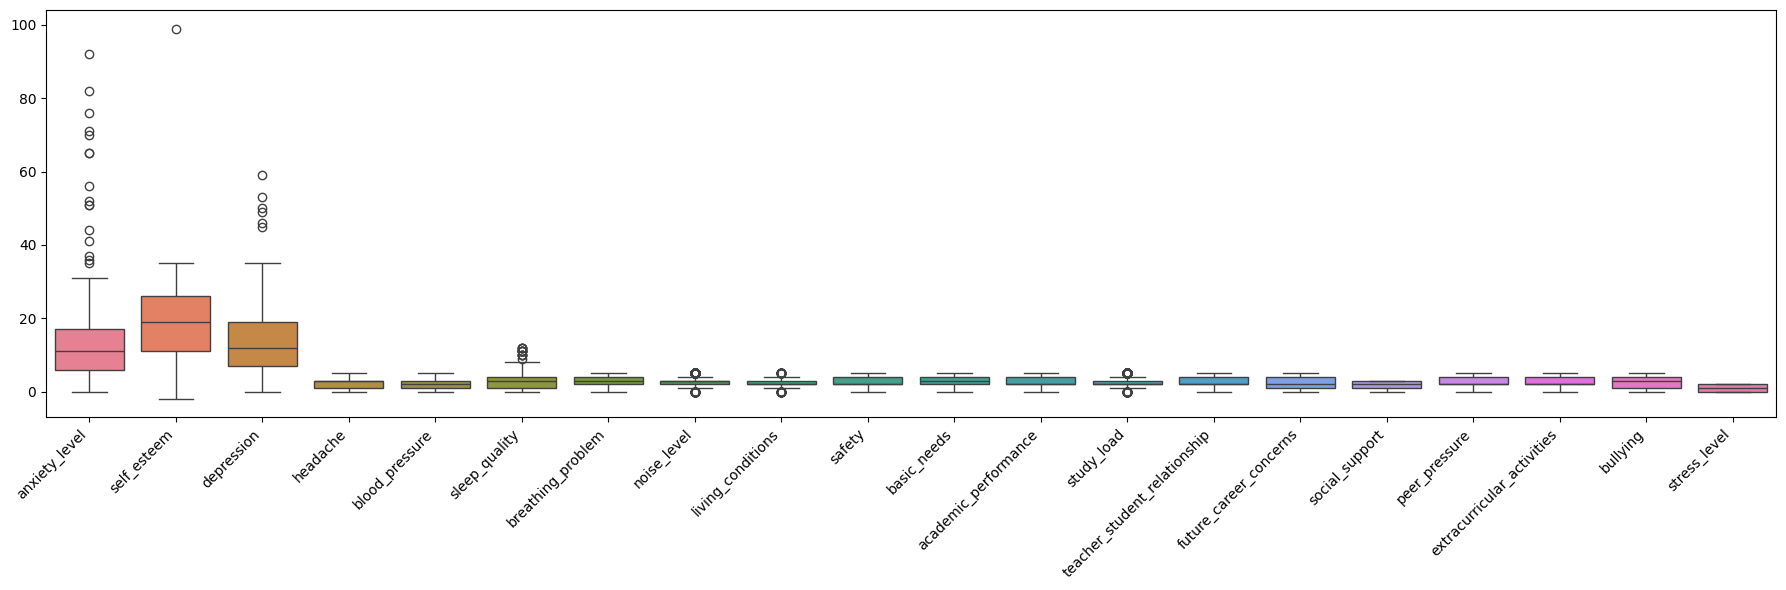

In [63]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [85]:
df['mental_health_history'] = df['mental_health_history'].astype(str).str.strip().str.lower()

mh_map = {
    'yes': 1, 'y': 1, 'true': 1, '1': 1, '1.0': 1,
    'no': 0,  'n': 0, 'false': 0, '0': 0, '0.0': 0,
    'nan': np.nan
}
df['mental_health_history'] = df['mental_health_history'].map(mh_map)

In [86]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1.0,25.0,3,3.0,10.0,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2
1,6.0,26.0,0.0,8.0,1,2.0,5.0,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0
2,5.0,25.0,NaN,6.0,1,2.0,4.0,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1.0,10.0,3,1.0,2.0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1
4,19.0,15.0,1.0,27.0,5,NaN,1.0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20.0,28.0,NaN,8.0,3,NaN,2.0,0.0,1,0,...,3,5.0,3,NaN,2.0,1.0,NaN,NaN,5.0,0
1096,13.0,23.0,0.0,NaN,3,1.0,2.0,2.0,3,3,...,3,2.0,3,2.0,2.0,3.0,2.0,3.0,2.0,1
1097,7.0,22.0,0.0,1.0,5,3.0,5.0,3.0,5,5,...,2,2.0,5,3.0,4.0,NaN,1.0,4.0,4.0,2
1098,13.0,20.0,0.0,9.0,2,1.0,3.0,4.0,3,3,...,2,3.0,2,3.0,2.0,3.0,3.0,3.0,NaN,1


In [15]:
df['academic_performance'] = pd.to_numeric(df['academic_performance'], errors='coerce')
df['academic_performance'] = df['academic_performance'].round().astype('Int64')

In [16]:
valid_ranges = {
    'anxiety_level':   (0, 21),
    'self_esteem':     (0, 30),
    'depression':      (0, 27),
    'sleep_quality':   (0, 5),
    'blood_pressure':  (1, 3),
}

for col, (lo, hi) in valid_ranges.items():
    df[col] = pd.to_numeric(df[col], errors='coerce')
    mask = (df[col] < lo) | (df[col] > hi)
    print(f"{col}: {mask.sum()} out-of-range values → set to NaN")
    df.loc[mask, col] = np.nan

anxiety_level: 18 out-of-range values → set to NaN
self_esteem: 12 out-of-range values → set to NaN
depression: 10 out-of-range values → set to NaN
sleep_quality: 20 out-of-range values → set to NaN
blood_pressure: 15 out-of-range values → set to NaN


In [17]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [18]:
print("\nMissing values after cleaning:")
mv = df.isnull().sum()
print(mv[mv > 0].sort_values(ascending=False))
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values after cleaning:
blood_pressure                  124
social_support                  121
sleep_quality                   108
extracurricular_activities       99
mental_health_history            97
anxiety_level                    94
bullying                         88
self_esteem                      78
peer_pressure                    77
teacher_student_relationship     66
breathing_problem                66
depression                       65
future_career_concerns           55
dtype: int64

Total missing cells: 1138


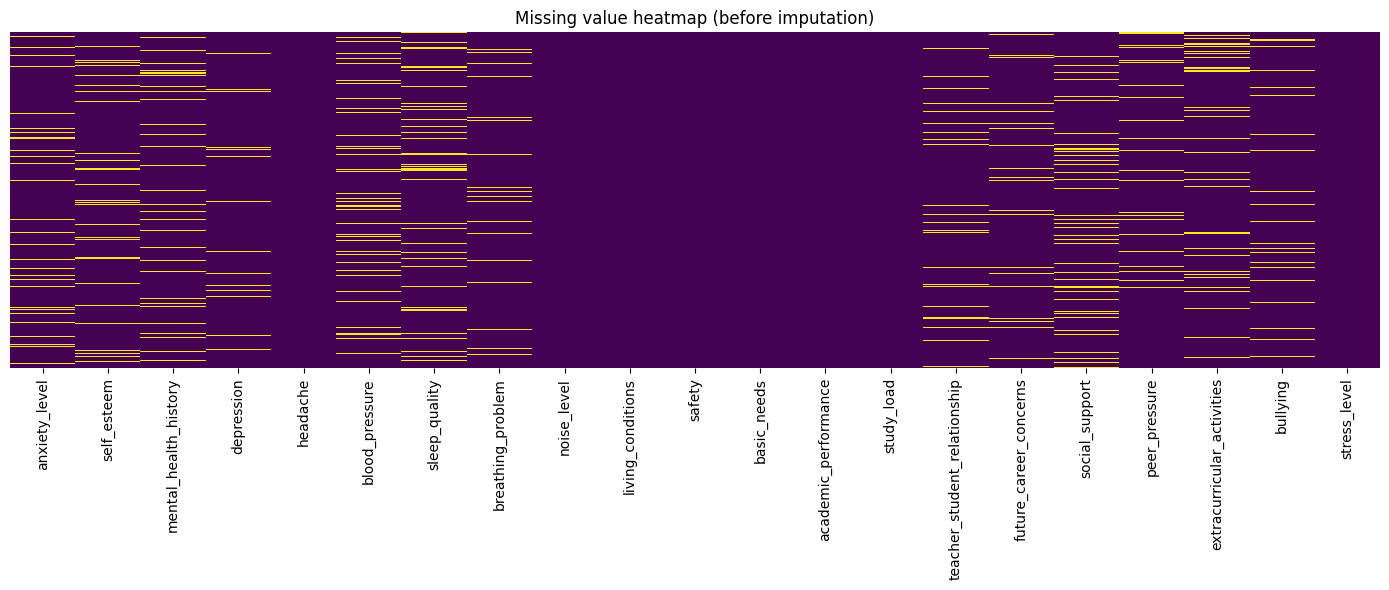

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing value heatmap (before imputation)')
plt.tight_layout()
plt.show()

In [79]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df),
    columns=df.columns
)

# Cast back to int since all values are ordinal
df_imputed = df_imputed.round().astype(int)

print("Shape after imputation:", df_imputed.shape)
print("Any nulls remaining:", df_imputed.isnull().sum().sum())

Shape after imputation: (1100, 21)
Any nulls remaining: 0


In [80]:
df

,anxiety_level,self_esteem,mental_health_history,depression,headache,blood_pressure,sleep_quality,breathing_problem,noise_level,living_conditions,...,basic_needs,academic_performance,study_load,teacher_student_relationship,future_career_concerns,social_support,peer_pressure,extracurricular_activities,bullying,stress_level
0,18.0,8.0,1.0,25.0,3,3.0,10.0,5.0,3,1,...,2,1.0,5,2.0,5.0,1.0,NaN,5.0,4.0,2
1,6.0,26.0,0.0,8.0,1,2.0,5.0,2.0,2,4,...,4,4.0,1,4.0,1.0,3.0,2.0,NaN,1.0,0
2,5.0,25.0,NaN,6.0,1,2.0,4.0,1.0,2,4,...,4,4.0,2,NaN,1.0,3.0,2.0,1.0,1.0,0
3,12.0,23.0,1.0,10.0,3,1.0,2.0,2.0,2,3,...,2,2.0,3,3.0,3.0,3.0,NaN,3.0,3.0,1
4,19.0,15.0,1.0,27.0,5,NaN,1.0,4.0,5,2,...,2,2.0,5,1.0,4.0,1.0,4.0,5.0,5.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,20.0,28.0,NaN,8.0,3,NaN,2.0,0.0,1,0,...,3,5.0,3,NaN,2.0,1.0,NaN,NaN,5.0,0
1096,13.0,23.0,0.0,NaN,3,1.0,2.0,2.0,3,3,...,3,2.0,3,2.0,2.0,3.0,2.0,3.0,2.0,1
1097,7.0,22.0,0.0,1.0,5,3.0,5.0,3.0,5,5,...,2,2.0,5,3.0,4.0,NaN,1.0,4.0,4.0,2
1098,13.0,20.0,0.0,9.0,2,1.0,3.0,4.0,3,3,...,2,3.0,2,3.0,2.0,3.0,3.0,3.0,NaN,1


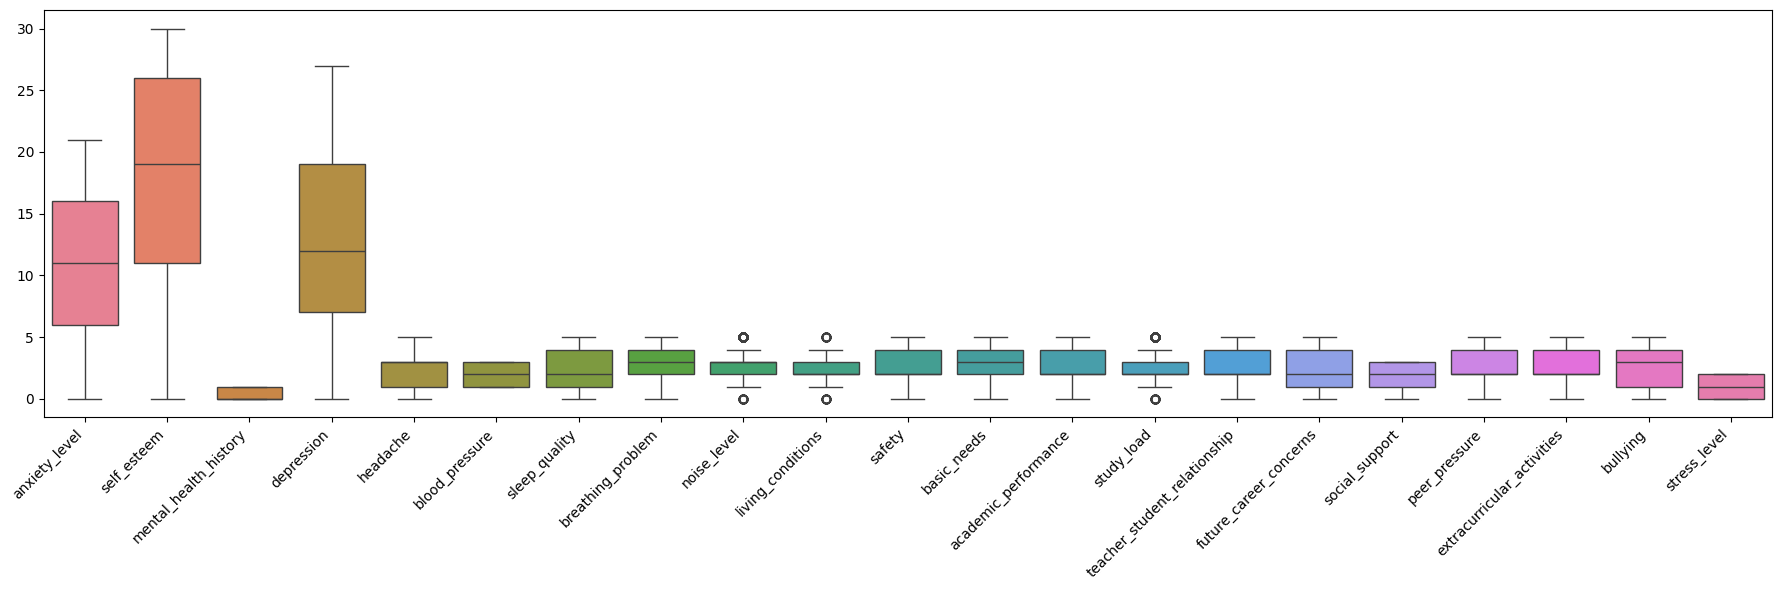

In [23]:
plt.figure(figsize=(18, 6))
sns.boxplot(data=df)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
for col in ['noise_level', 'living_conditions', 'study_load']:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, unique={sorted(df[col].unique())}")

noise_level: min=0, max=5, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
living_conditions: min=0, max=5, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
study_load: min=0, max=5, unique=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [25]:
df_imputed.to_csv('../data/processed/StressLevelDataset_cleaned.csv', index=False)

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anxiety_level                 1024 non-null   float64
 1   self_esteem                   1034 non-null   float64
 2   mental_health_history         1003 non-null   float64
 3   depression                    1045 non-null   float64
 4   headache                      1100 non-null   int64  
 5   blood_pressure                991 non-null    float64
 6   sleep_quality                 1012 non-null   float64
 7   breathing_problem             1034 non-null   float64
 8   noise_level                   1100 non-null   int64  
 9   living_conditions             1100 non-null   int64  
 10  safety                        1100 non-null   int64  
 11  basic_needs                   1100 non-null   int64  
 12  academic_performance          1100 non-null   float64
 13  stu

In [91]:
df_imputed.isna().sum()

anxiety_level                   0
self_esteem                     0
mental_health_history           0
depression                      0
headache                        0
blood_pressure                  0
sleep_quality                   0
breathing_problem               0
noise_level                     0
living_conditions               0
safety                          0
basic_needs                     0
academic_performance            0
study_load                      0
teacher_student_relationship    0
future_career_concerns          0
social_support                  0
peer_pressure                   0
extracurricular_activities      0
bullying                        0
stress_level                    0
dtype: int64

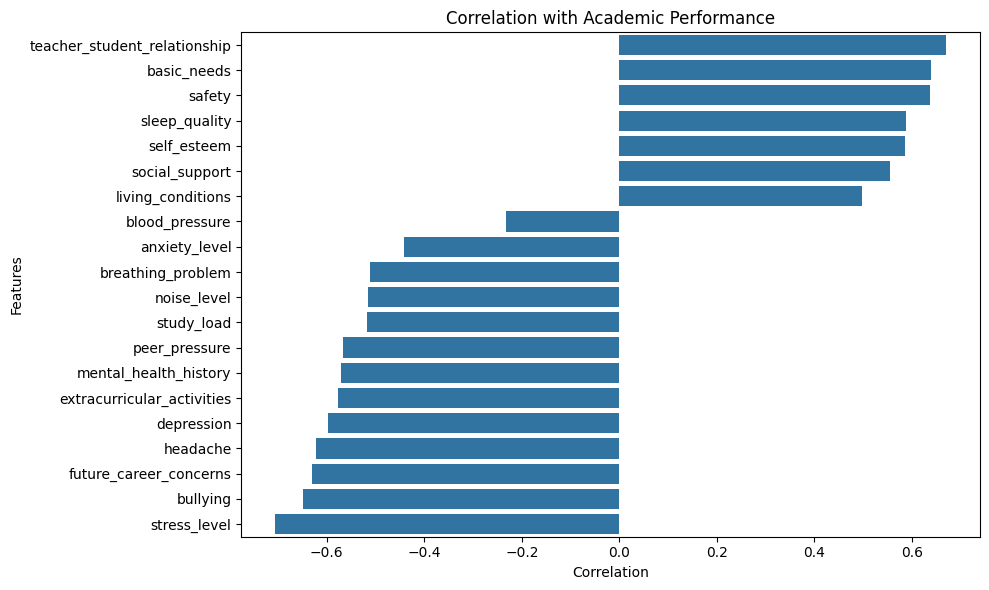

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_with_target = (
    df.corr(numeric_only=True)['academic_performance']
    .drop('academic_performance')
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)

plt.title('Correlation with Academic Performance')
plt.xlabel('Correlation')
plt.ylabel('Features')
plt.tight_layout()
plt.show()